In [1]:
import os

from IPython.core.display import Image
from IPython.core.magics import display
from dotenv import load_dotenv
from langchain_community.chat_models import ChatTongyi
from langchain_deepseek import ChatDeepSeek
load_dotenv()

class LLM:
    def __init__(self, mode:str = 'qwen'):
        self.model_mode = mode

    def get_model(self):
        if self.model_mode == "qwen":
            llm = self.qwen_llm()
        else:
            llm = self.deepseek_model()
        return llm

    def deepseek_model(self):
        deepseek_model = ChatDeepSeek(
            model=os.environ.get("DEEPSEEK_MODEL"),
            temperature=0,
            max_tokens=None,
            timeout=None,
            max_retries=2,
        )
        return deepseek_model

    def qwen_llm(self):
        return ChatTongyi(
            model=os.environ.get("DASHSCOPE_MODEL"),
            api_key=os.environ.get("DASHSCOPE_API_KEY"),
            max_retries=2,
        )







/var/folders/1c/4303134j5y7f7vsn2m6szlwh0000gn/T/ipykernel_4738/1365138393.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.chat_models import ChatTongyi


In [2]:
from langgraph.graph import MessagesState

class CalculateState(MessagesState):
    pass

In [4]:
from __future__ import annotations

from langchain.tools import tool

@tool
def add(a: int, b: int) -> int:
    """计算两个整数的加法，只能用于求和运算
    Args:
        a: 整型数字，加法第一个加数
        b: 整型数字，加法第二个加数
    """
    return a + b

@tool
def subtract(a:int, b:int) -> int:
    """计算两数相减
    Args:
        a：减数1
        b：减数2
    """
    return a - b

@tool
def multiply(a: int, b: int) -> int:
    """计算两个数字相乘
    Args:
        a: 乘数1
        b: 乘数2
    """
    return a * b


@tool
def divide(a: int, b: int):
    """计算两个数字相乘
    Args:
        a: 被除数1
        b: 除数2
    """
    if b == 0:
        return 0
    return a / b

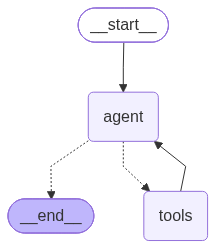

In [6]:
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
# 绘图必须的两个库
from IPython.display import display, Image

import os

# from app.llm import LLM
# from app.state import CalculateState
# from app.tools import add,subtract,multiply,divide

tools = [add,subtract,multiply,divide]
tool_node = ToolNode(tools)

def should_continue(state: CalculateState):
    last_message = state["messages"][-1]
    tool_calls = getattr(last_message,"tool_calls",[])
    print("====tool_calls:", tool_calls)
    if tool_calls:
        return "tools"
    else:
        return END

def call_llm(state: CalculateState):
    """调用大模型"""
    mode = os.environ.get("MODEL_MODE")
    messages = state['messages']
    response = LLM(mode=mode).get_model().bind_tools(tools).invoke(messages)
    return {"response": [response]}

graph = StateGraph(CalculateState)

graph.add_node("agent", call_llm)
graph.add_node("tools", tool_node)

graph.add_edge(START,"agent")
graph.add_conditional_edges("agent", should_continue, ["tools", END])
graph.add_edge("tools","agent")

app = graph.compile()
display(Image(app.get_graph().draw_mermaid_png()))


In [11]:
def get_result(input: str):
    prompt = """你是一位数学专家，可以根据客户的需求计算相对应的数的处理，如果不是数学问题，请给出不在职责范围内的回答,你的回答需要调用本地的tools工具"""
    messages = {
        "messages": [
            SystemMessage(content=prompt),
            HumanMessage(content=input),
        ]
    }

    config = {
        "configurable": {
            "thread_id": "1"
        }
    }

    chunks = app.stream(messages, config=config, stream_mode="messages")
    # full_text = ""
    # full_reason = ""
    for chunk,meta in chunks:
        print(chunk, end="|", flush=True)
        if chunk.content:
            print(chunk.content,end="|", flush=True)


In [12]:
input = "计算 123456加上789012再乘上3000再减100再除100"
result = get_result(input)
print(result)


====tool_calls:content='好的，我来按照顺序逐步计算这个表达式。\n\n**第一步：计算 123456 + 789012**\n\n' additional_kwargs={'tool_calls': [{'function': {'arguments': '{"a": 123456, "b": 789012}', 'name': 'add'}, 'id': 'call_8e62d427c0b646d38873bbfd', 'index': 0, 'type': 'function'}]} response_metadata={'model_name': 'qwen3.7-max', 'finish_reason': 'tool_calls', 'request_id': 'febad5c1-1829-9154-9d2a-b511b5074132', 'token_usage': {'input_tokens': 633, 'output_tokens': 305, 'output_tokens_details': {'reasoning_tokens': 224}, 'prompt_tokens_details': {'cached_tokens': 0}, 'total_tokens': 938}} id='lc_run--019f8d26-61e3-7060-b444-a9ef48415f68-0' tool_calls=[{'name': 'add', 'args': {'a': 123456, 'b': 789012}, 'id': 'call_8e62d427c0b646d38873bbfd', 'type': 'tool_call'}] invalid_tool_calls=[]| []
好的，我来按照顺序逐步计算这个表达式。

**第一步：计算 123456 + 789012**

|None
